In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from sklearn.metrics import confusion_matrix, classification_report
import itertools

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')

Using device: cuda
PyTorch version: 2.7.1+cu118


In [2]:
TRAIN_DIR = Path('./veggie_heap_training')
TEST_DIR  = Path('./veggie_heap_testing')

IMG_SIZE  = 64   # resizing all images to 64x64
BATCH_SIZE = 128
EPOCHS     = 10
LR         = 1e-3

# Discover classes from training folder (skip non-directories like vacation_photos)
SKIP_FOLDERS = {'vacation_photos'}

classes = sorted([
    d.name for d in TRAIN_DIR.iterdir()
    if d.is_dir() and d.name not in SKIP_FOLDERS
])

class_to_idx = {cls: i for i, cls in enumerate(classes)}
idx_to_class = {i: cls for cls, i in class_to_idx.items()}
NUM_CLASSES  = len(classes)

# short names for plots (just the veggie part)
def short_name(full_name):
    """Extracts veggie from folder name,'Apatosaur Aphie's Apples' will be taken as 'Apples' """
    return full_name.split()[-1]

short_classes = [short_name(c) for c in classes]

print(f'\n Found {NUM_CLASSES} classes:')
for i, (full, short) in enumerate(zip(classes, short_classes)):
    print(f'  [{i:2d}] {short:15s}  ←  {full}')


 Found 11 classes:
  [ 0] Apples           ←  Apatosaur Aphie's Apples
  [ 1] Blueberries      ←  Bluplocephalus Bob's Blueberries
  [ 2] Cherries         ←  Cherizinoasaur Cher's Cherries
  [ 3] Corn             ←  Corythosaurus Cory's Corn
  [ 4] Grapes           ←  Grapthorina Greta's Grapes
  [ 5] Peaches          ←  Pachycephalosaurus Perry's Peaches
  [ 6] Peppers          ←  Pepteranodon Pep's Peppers
  [ 7] Potatoes         ←  Potoceratops Pott's Potatoes
  [ 8] Raspberries      ←  Rhaspdodon Ribery's Raspberries
  [ 9] Strawberries     ←  Stribecosaurus Stan's Strawberries
  [10] Thyme            ←  Thyreosaur Tim's Thyme


## 3. Custom Dataset & Augmentation

In [3]:
class VeggieDataset(Dataset):
    """Custom Dataset that loads images from the dinosaur veggie folders."""

    VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

    def __init__(self, root_dir, class_to_idx, transform=None, skip=None):
        self.root_dir     = Path(root_dir)
        self.class_to_idx = class_to_idx
        self.transform    = transform
        self.skip         = skip or set()
        self.samples      = []   # list of (path, label)
        self._scan()

    def _scan(self):
        for cls_folder in self.root_dir.iterdir():
            if not cls_folder.is_dir():
                continue
            if cls_folder.name in self.skip:
                continue
            if cls_folder.name not in self.class_to_idx:
                continue
            label = self.class_to_idx[cls_folder.name]
            for img_path in cls_folder.iterdir():
                if img_path.suffix.lower() in self.VALID_EXTS:
                    self.samples.append((img_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label


# ── Transforms ──────────────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomRotation(degrees=20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

# ── Datasets & Loaders ──────────────────────────────────────────────────────
train_dataset = VeggieDataset(TRAIN_DIR, class_to_idx, train_transform, SKIP_FOLDERS)
test_dataset  = VeggieDataset(TEST_DIR,  class_to_idx, test_transform,  SKIP_FOLDERS)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=False,
                          persistent_workers=False, prefetch_factor=None)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False,
                          persistent_workers=False, prefetch_factor=None)

print(f'Training samples : {len(train_dataset)}')
print(f'Testing  samples : {len(test_dataset)}')
print(f'Training batches : {len(train_loader)}')
print(f'Testing  batches : {len(test_loader)}')

Training samples : 8905
Testing  samples : 2211
Training batches : 70
Testing  batches : 18


## 4. Dataset Distribution 

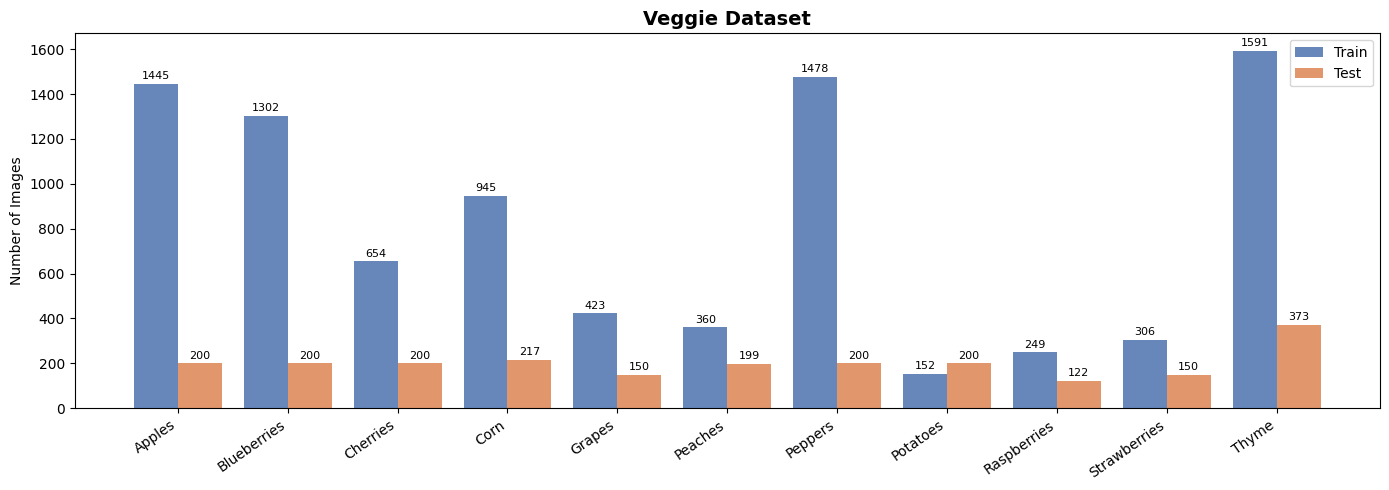

Saved class_distribution.png


In [4]:
# Count samples per class
from collections import Counter

train_counts = Counter(label for _, label in train_dataset.samples)
test_counts  = Counter(label for _, label in test_dataset.samples)

x = np.arange(NUM_CLASSES)
train_vals = [train_counts[i] for i in range(NUM_CLASSES)]
test_vals  = [test_counts[i]  for i in range(NUM_CLASSES)]

fig, ax = plt.subplots(figsize=(14, 5))
bars1 = ax.bar(x - 0.2, train_vals, 0.4, label='Train', color='#4C72B0', alpha=0.85)
bars2 = ax.bar(x + 0.2, test_vals,  0.4, label='Test',  color='#DD8452', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(short_classes, rotation=35, ha='right', fontsize=10)
ax.set_ylabel('Number of Images')
ax.set_title("Veggie Dataset", fontsize=14, fontweight='bold')
ax.legend()
ax.bar_label(bars1, padding=2, fontsize=8)
ax.bar_label(bars2, padding=2, fontsize=8)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print('Saved class_distribution.png')

In [5]:
print('Step 1: accessing dataset...')
print(f'Total samples: {len(train_dataset)}')

print('Step 2: loading single image...')
img, label = train_dataset[0]
print(f'Image shape: {img.shape}')

print('Step 3: loading single image 2...')
img, label = train_dataset[1]
print(f'Image shape: {img.shape}')

print('Step 4: creating iterator...')
it = iter(train_loader)
print('Iterator created')

print('Step 5: fetching batch...')
imgs, labels = next(it)
print(f'Batch shape: {imgs.shape}')

print('All steps passed!')

Step 1: accessing dataset...
Total samples: 8905
Step 2: loading single image...
Image shape: torch.Size([3, 64, 64])
Step 3: loading single image 2...
Image shape: torch.Size([3, 64, 64])
Step 4: creating iterator...
Iterator created
Step 5: fetching batch...
Batch shape: torch.Size([128, 3, 64, 64])
All steps passed!


## 5. Sample Images Grid

Testing single image load...
Single image OK — shape: torch.Size([3, 64, 64]), label: 0
Loading first batch...
Batch loaded — shape: torch.Size([128, 3, 64, 64])


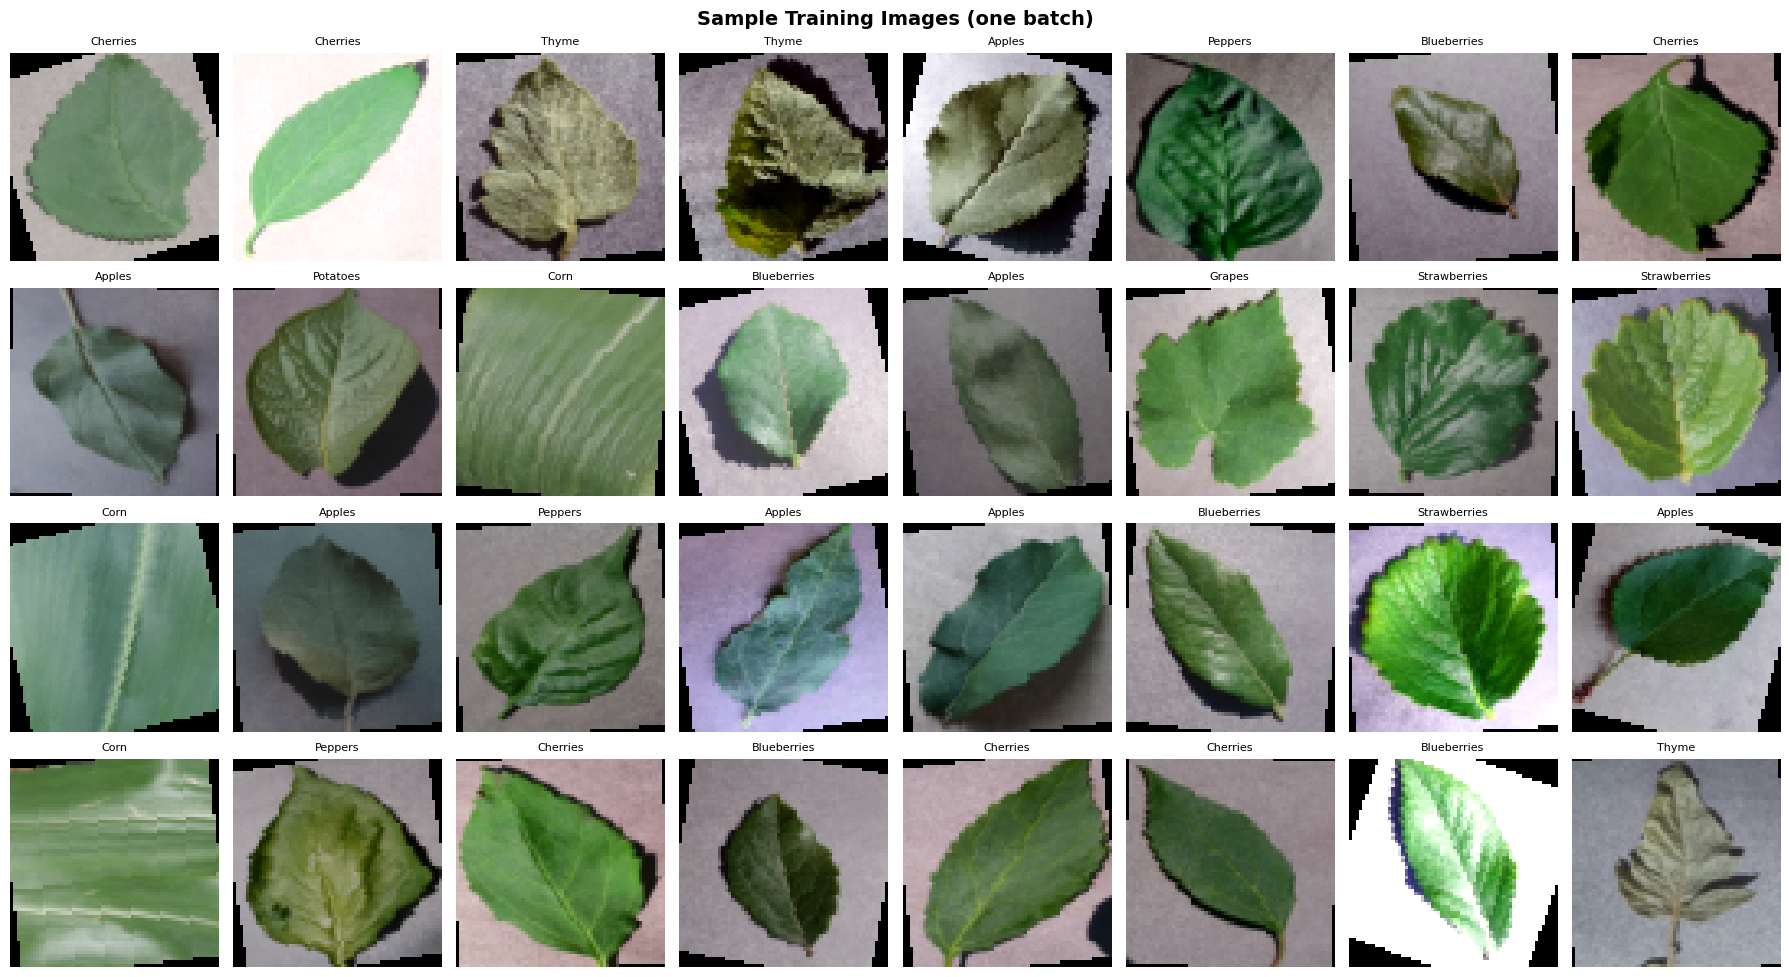

Saved sample_images.png


In [6]:
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return (tensor.cpu() * std + mean).clamp(0, 1)

# Test loading just ONE image first
print('Testing single image load...')
img, label = train_dataset[0]
print(f'Single image OK — shape: {img.shape}, label: {label}')

# Now try a full batch
print('Loading first batch...')
imgs, labels = next(iter(train_loader))
print(f'Batch loaded — shape: {imgs.shape}')

n_show = min(len(imgs), 32)
cols = 8
rows = (n_show + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 2.5))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i >= n_show:
        ax.axis('off')
        continue
    img = denormalize(imgs[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(short_classes[labels[i].item()], fontsize=8)
    ax.axis('off')

fig.suptitle("Sample Training Images (one batch)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()
print('Saved sample_images.png')

## 6. CNN Architecture

In [7]:
class VeggieCNN(nn.Module):
    """
    Custom CNN — no pretrained weights.
    Architecture:
        Block 1: Conv(3→32)  → BN → ReLU → Conv(32→32)  → BN → ReLU → MaxPool → Dropout
        Block 2: Conv(32→64) → BN → ReLU → Conv(64→64)  → BN → ReLU → MaxPool → Dropout
        Block 3: Conv(64→128)→ BN → ReLU → Conv(128→128)→ BN → ReLU → MaxPool → Dropout
        Block 4: Conv(128→256)→BN → ReLU → Conv(256→256)→ BN → ReLU → MaxPool → Dropout
        Head:    AdaptiveAvgPool → FC(256→512) → BN → ReLU → Dropout → FC(512→num_classes)
    """

    def __init__(self, num_classes=11):
        super().__init__()

        def conv_block(in_ch, out_ch, drop=0.25):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2),
                nn.Dropout2d(drop),
            )

        self.features = nn.Sequential(
            conv_block(  3,  32, drop=0.15),   # 128→64
            conv_block( 32,  64, drop=0.20),   # 64→32
            conv_block( 64, 128, drop=0.25),   # 32→16
            conv_block(128, 256, drop=0.30),   # 16→8
        )

        self.pool = nn.AdaptiveAvgPool2d((2, 2))  # → 256×2×2 = 1024

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 2 * 2, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)


model = VeggieCNN(num_classes=NUM_CLASSES).to(device)

# ── Model summary ────────────────────────────────────────────────────────────
total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model Architecture:\n{model}')
print(f'\nTotal parameters     : {total_params:,}')
print(f'Trainable parameters : {train_params:,}')

Model Architecture:
VeggieCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (7): Dropout2d(p=0.15, inplace=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=

## 7. Optimizer, Scheduler & Loss

In [8]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

print(f'Criterion : CrossEntropyLoss (label_smoothing=0.1)')
print(f'Optimizer : AdamW  (lr={LR}, weight_decay=1e-4)')
print(f'Scheduler : CosineAnnealingLR (T_max={EPOCHS})')

Criterion : CrossEntropyLoss (label_smoothing=0.1)
Optimizer : AdamW  (lr=0.001, weight_decay=1e-4)
Scheduler : CosineAnnealingLR (T_max=10)


## 8. Training & Validation Loop

In [ ]:
def run_epoch(model, loader, criterion, optimizer=None, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            loss   = criterion(logits, labels)

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item() * imgs.size(0)
            preds  = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += imgs.size(0)

    return total_loss / total, correct / total


# ── Training loop ────────────────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc  = 0.0
best_model_path = 'best_veggie_cnn.pth'

print(f'{'Epoch':>6} | {'Tr Loss':>8} | {'Tr Acc':>7} | {'Va Loss':>8} | {'Va Acc':>7} | {'LR':>8}')
print('-' * 58)

for epoch in range(1, EPO  CHS + 1):
    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, train=True)
    va_loss, va_acc = run_epoch(model, test_loader,  criterion, train=False)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(va_acc)

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save(model.state_dict(), best_model_path)
        flag = ' ✅'
    else:
        flag = ''

    lr_now = scheduler.get_last_lr()[0]
    print(f'{epoch:>6} | {tr_loss:>8.4f} | {tr_acc:>6.2%} | {va_loss:>8.4f} | {va_acc:>6.2%} | {lr_now:>8.2e}{flag}')

print(f'\n Best validation accuracy: {best_val_acc:.2%}')

 Epoch |  Tr Loss |  Tr Acc |  Va Loss |  Va Acc |       LR
----------------------------------------------------------
     1 |   1.9255 | 46.05% |   1.7872 | 55.00% | 9.76e-04 ✅
     2 |   1.3391 | 66.64% |   1.6556 | 50.93% | 9.05e-04
     3 |   1.1866 | 73.63% |   1.4843 | 58.25% | 7.94e-04 ✅
     4 |   1.0737 | 78.67% |   1.4977 | 61.10% | 6.55e-04 ✅
     5 |   1.0079 | 80.83% |   1.3471 | 66.53% | 5.01e-04 ✅
     6 |   0.9586 | 83.13% |   1.3218 | 66.98% | 3.46e-04 ✅
     7 |   0.9146 | 85.36% |   1.2407 | 70.65% | 2.07e-04 ✅
     8 |   0.8883 | 86.37% |   1.2048 | 72.46% | 9.64e-05 ✅
     9 |   0.8650 | 87.52% |   1.2459 | 70.47% | 2.54e-05
    10 |   0.8556 | 87.66% |   1.2584 | 70.38% | 1.00e-06

 Best validation accuracy: 72.46%


## 9. Training Curves

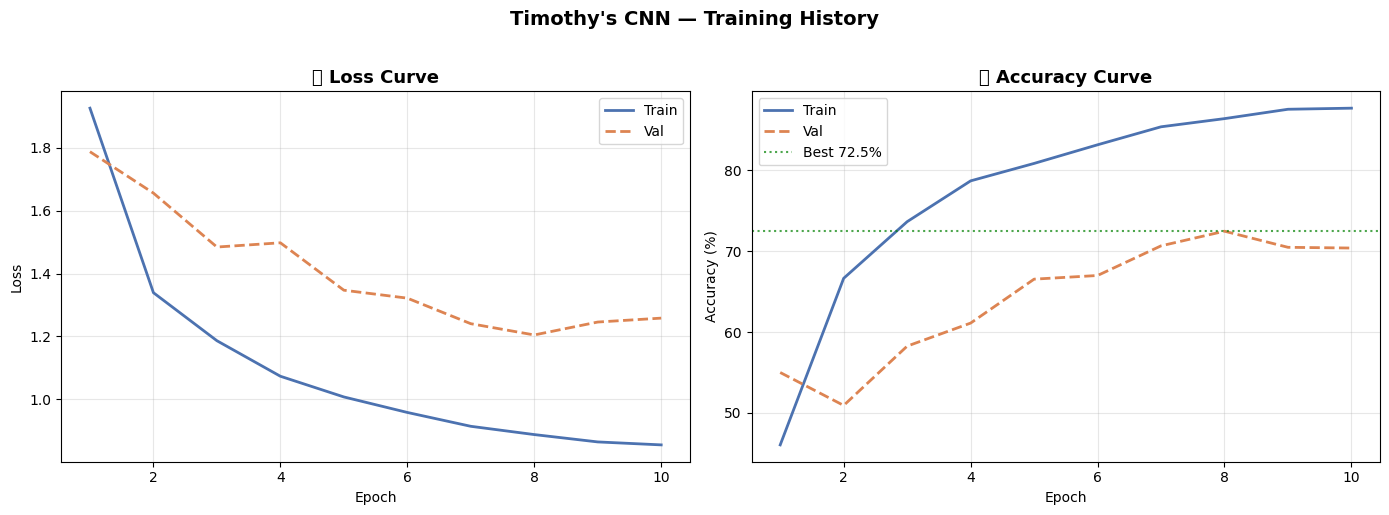

Saved training_curves.png


In [10]:
epochs_x = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(epochs_x, history['train_loss'], label='Train', color='#4C72B0', linewidth=2)
ax1.plot(epochs_x, history['val_loss'],   label='Val',   color='#DD8452', linewidth=2, linestyle='--')
ax1.set_title('📉 Loss Curve', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(epochs_x, [a*100 for a in history['train_acc']], label='Train', color='#4C72B0', linewidth=2)
ax2.plot(epochs_x, [a*100 for a in history['val_acc']],   label='Val',   color='#DD8452', linewidth=2, linestyle='--')
ax2.axhline(best_val_acc*100, color='green', linestyle=':', alpha=0.7, label=f'Best {best_val_acc:.1%}')
ax2.set_title('📈 Accuracy Curve', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle("Timothy's CNN — Training History", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved training_curves.png')

## 10. Load Best Model & Full Evaluation

In [11]:
# Load best checkpoint
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        logits = model(imgs)
        probs  = F.softmax(logits, dim=1)
        preds  = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

final_acc = (all_preds == all_labels).mean()
print(f'\n Final Test Accuracy (best model): {final_acc:.2%}')
print('\n' + '='*60)
print(classification_report(all_labels, all_preds, target_names=short_classes))


 Final Test Accuracy (best model): 72.46%

              precision    recall  f1-score   support

      Apples       0.88      0.84      0.86       200
 Blueberries       0.58      0.99      0.73       200
    Cherries       0.92      0.99      0.95       200
        Corn       1.00      1.00      1.00       217
      Grapes       0.89      0.27      0.42       150
     Peaches       0.64      0.25      0.36       199
     Peppers       0.45      0.60      0.52       200
    Potatoes       0.70      0.34      0.45       200
 Raspberries       0.70      0.80      0.74       122
Strawberries       0.70      0.95      0.81       150
       Thyme       0.72      0.81      0.76       373

    accuracy                           0.72      2211
   macro avg       0.74      0.71      0.69      2211
weighted avg       0.74      0.72      0.70      2211



## 11. Confusion Matrix

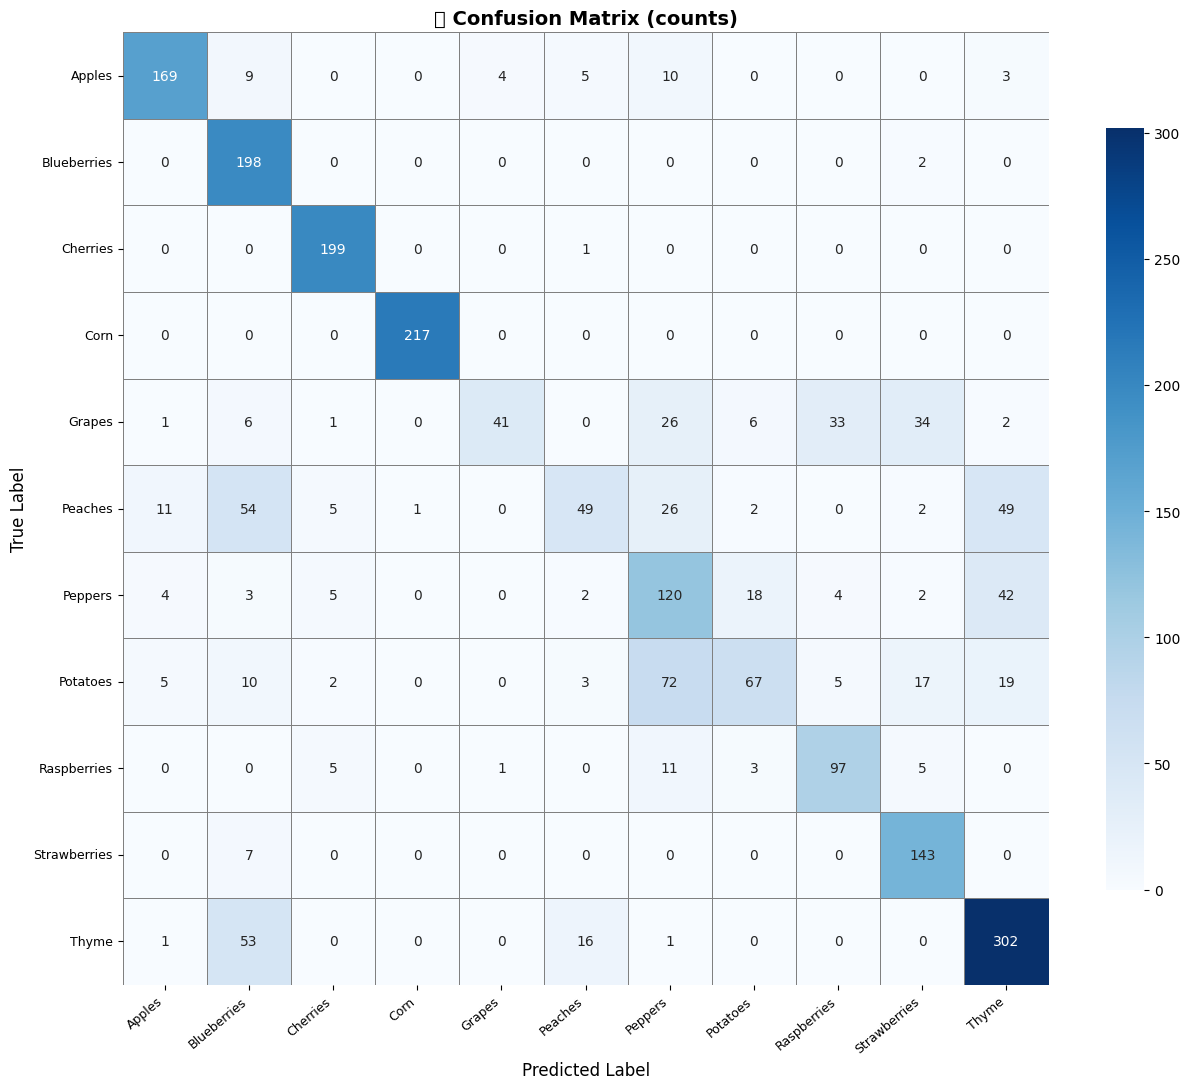

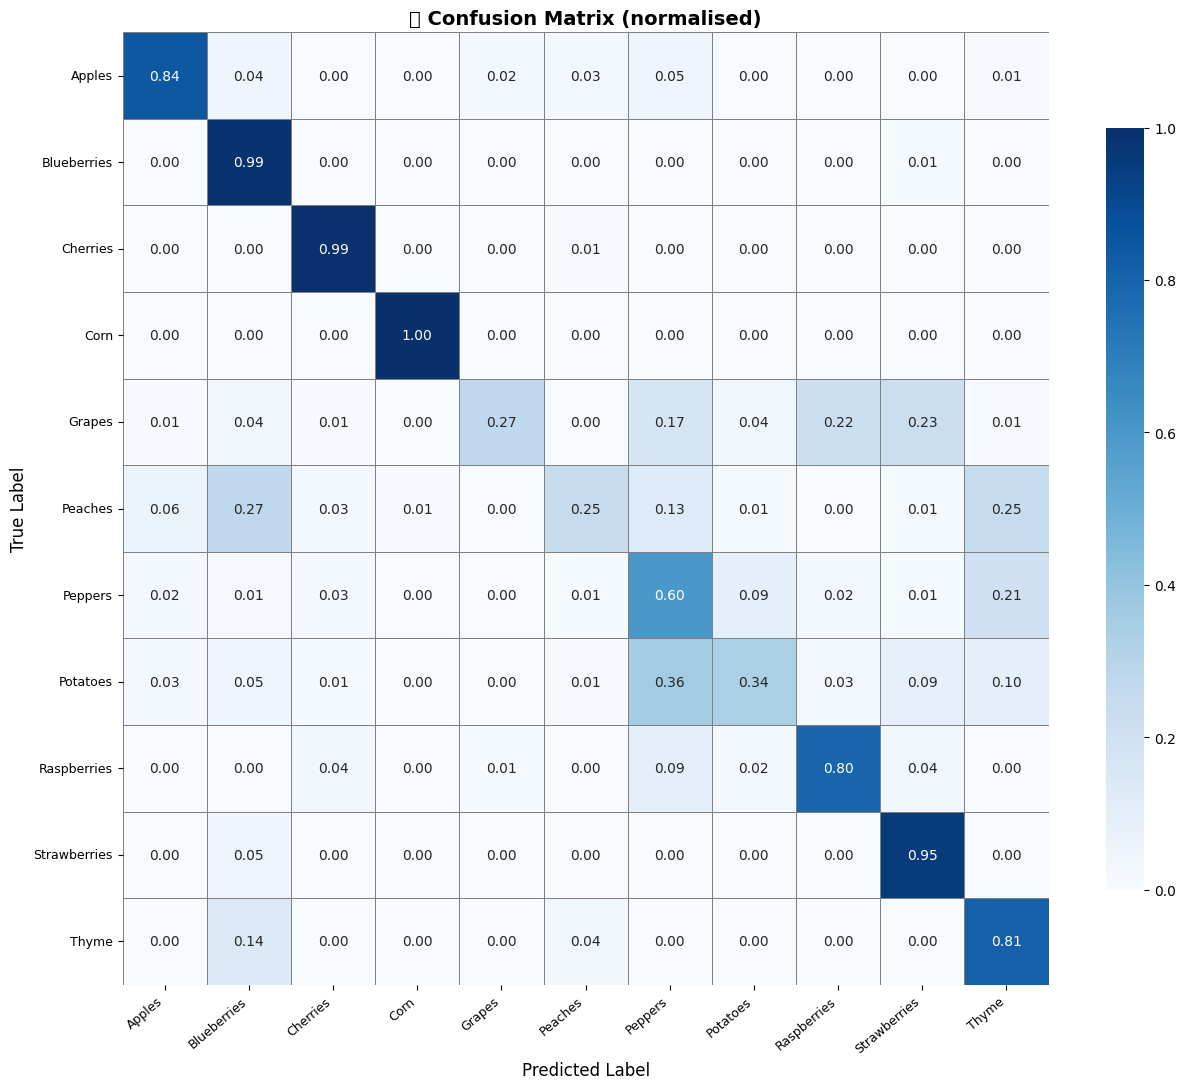

Saved confusion matrices.


In [12]:
def plot_confusion_matrix(y_true, y_pred, class_names, normalize=False, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
        fmt = '.2f'
    else:
        fmt = 'd'

    fig, ax = plt.subplots(figsize=(13, 11))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, linecolor='gray', ax=ax,
                cbar_kws={'shrink': 0.8})
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label',      fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    plt.xticks(rotation=40, ha='right', fontsize=9)
    plt.yticks(rotation=0,  fontsize=9)
    plt.tight_layout()
    return fig


# Raw counts
fig = plot_confusion_matrix(all_labels, all_preds, short_classes,
                             normalize=False,
                             title='🟦 Confusion Matrix (counts)')
fig.savefig('confusion_matrix_counts.png', dpi=150, bbox_inches='tight')
plt.show()

# Normalised
fig = plot_confusion_matrix(all_labels, all_preds, short_classes,
                             normalize=True,
                             title='🟦 Confusion Matrix (normalised)')
fig.savefig('confusion_matrix_norm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved confusion matrices.')

## 12. Per-Class Accuracy Bar Chart

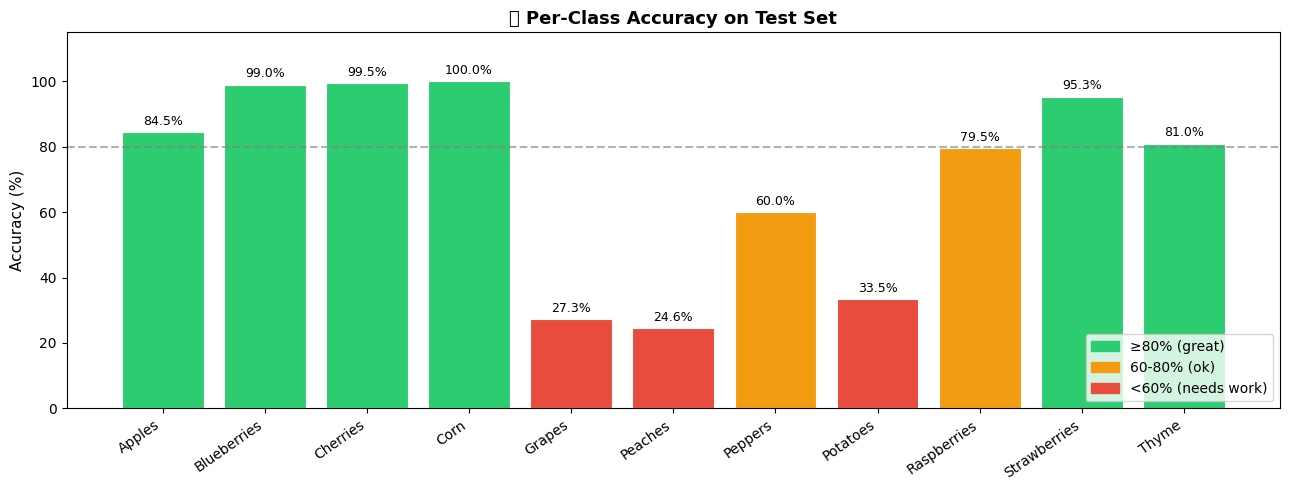

Saved per_class_accuracy.png


In [ ]:
cm = confusion_matrix(all_labels, all_preds)
per_class_acc = cm.diagonal() / cm.sum(axis=1)

colors = ['#2ecc71' if a >= 0.8 else '#f39c12' if a >= 0.6 else '#e74c3c'
          for a in per_class_acc]

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(short_classes, per_class_acc * 100, color=colors, edgecolor='white', linewidth=0.8)
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
ax.axhline(80, color='gray', linestyle='--', alpha=0.6, label='80% threshold')
ax.set_ylim(0, 115)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Per-Class Accuracy on Test Set', fontsize=13, fontweight='bold')
ax.set_xticklabels(short_classes, rotation=35, ha='right', fontsize=10)

legend_handles = [
    mpatches.Patch(color='#2ecc71', label='≥80%'),
    mpatches.Patch(color='#f39c12', label='60-80%'),
    mpatches.Patch(color='#e74c3c', label='<60%'),
]
ax.legend(handles=legend_handles, loc='lower right')
plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150)
plt.show()
print('Saved per_class_accuracy.png')

## 13. Prediction Grid (What Should Each Dinosaur Eat)

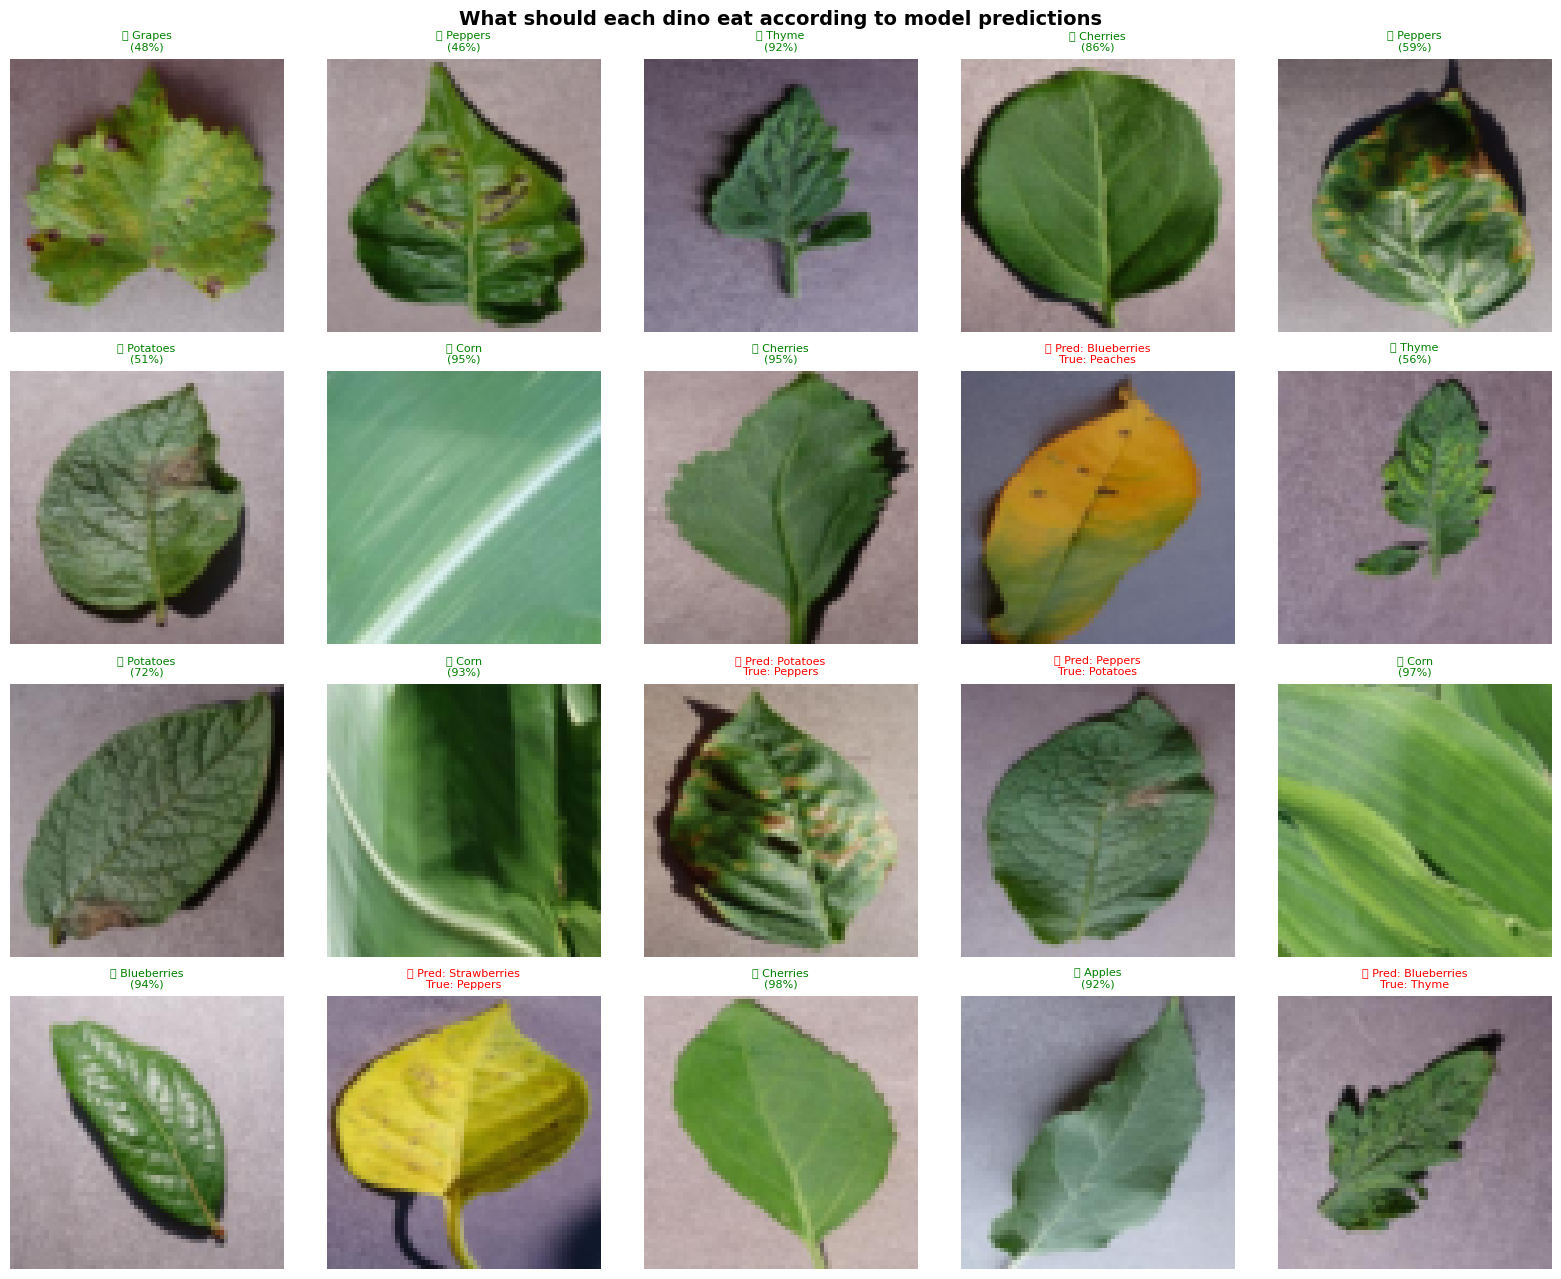

Saved predictions_grid.png


In [14]:
def show_predictions(dataset, model, num_images=20, title='Predictions'):
    model.eval()
    indices = np.random.choice(len(dataset), num_images, replace=False)

    fig, axes = plt.subplots(4, 5, figsize=(16, 13))
    axes = axes.flatten()

    with torch.no_grad():
        for ax, idx in zip(axes, indices):
            img_t, true_label = dataset[idx]
            logits = model(img_t.unsqueeze(0).to(device))
            prob   = F.softmax(logits, dim=1)
            pred   = logits.argmax(dim=1).item()
            conf   = prob[0, pred].item()

            img_display = denormalize(img_t).permute(1, 2, 0).numpy()
            ax.imshow(img_display)

            correct = (pred == true_label)
            border_color = '#2ecc71' if correct else '#e74c3c'
            for spine in ax.spines.values():
                spine.set_edgecolor(border_color)
                spine.set_linewidth(3)

            label_str = (f'✅ {short_classes[pred]}\n({conf:.0%})'
                         if correct else
                         f'❌ Pred: {short_classes[pred]}\nTrue: {short_classes[true_label]}')
            ax.set_title(label_str, fontsize=8,
                         color='green' if correct else 'red')
            ax.axis('off')

    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    return fig


fig = show_predictions(test_dataset, model, num_images=20,
                       title="What should each dino eat according to model predictions")
fig.savefig('predictions_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved predictions_grid.png')

## 14. Top-K Confidence Distribution

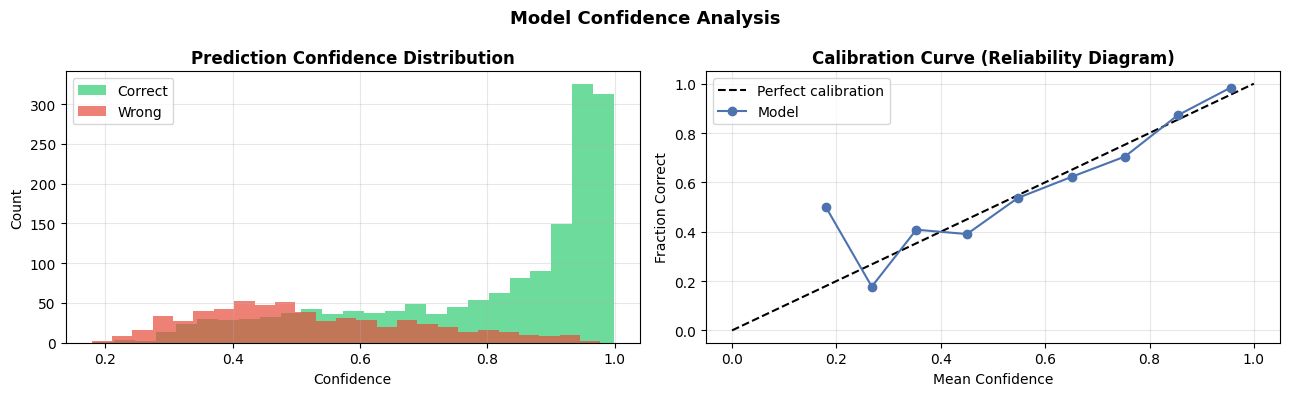

Saved confidence_analysis.png


In [15]:
correct_mask = (all_preds == all_labels)
top1_conf    = all_probs[np.arange(len(all_labels)), all_preds]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Confidence histogram split by correct/incorrect
axes[0].hist(top1_conf[correct_mask],  bins=25, alpha=0.7, color='#2ecc71', label='Correct')
axes[0].hist(top1_conf[~correct_mask], bins=25, alpha=0.7, color='#e74c3c', label='Wrong')
axes[0].set_xlabel('Confidence'); axes[0].set_ylabel('Count')
axes[0].set_title('Prediction Confidence Distribution', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Reliability diagram (calibration)
n_bins = 10
bin_edges = np.linspace(0, 1, n_bins + 1)
mean_conf_list, frac_pos_list = [], []
for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    mask = (top1_conf >= lo) & (top1_conf < hi)
    if mask.sum() > 0:
        mean_conf_list.append(top1_conf[mask].mean())
        frac_pos_list.append(correct_mask[mask].mean())

axes[1].plot([0,1],[0,1], 'k--', label='Perfect calibration')
axes[1].plot(mean_conf_list, frac_pos_list, 'o-', color='#4C72B0', label='Model')
axes[1].set_xlabel('Mean Confidence'); axes[1].set_ylabel('Fraction Correct')
axes[1].set_title('Calibration Curve (Reliability Diagram)', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Model Confidence Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confidence_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved confidence_analysis.png')

## 15. Most Confused Classes

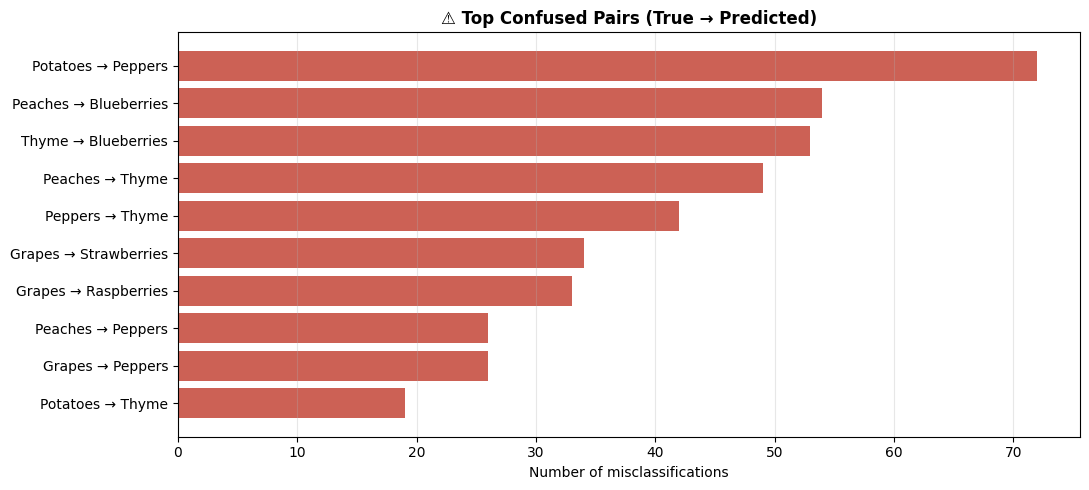

Saved top_confusions.png


In [16]:
# Which pairs does the model confuse most?
cm_raw = confusion_matrix(all_labels, all_preds)
np.fill_diagonal(cm_raw, 0)   # zero out correct predictions

confusions = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm_raw[i, j] > 0:
            confusions.append((cm_raw[i, j], short_classes[i], short_classes[j]))

confusions.sort(reverse=True)
top_n = min(10, len(confusions))

if top_n > 0:
    counts, trues, preds_ = zip(*confusions[:top_n])
    labels_x = [f'{t} → {p}' for t, p in zip(trues, preds_)]

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.barh(labels_x[::-1], counts[::-1], color='#c0392b', alpha=0.8)
    ax.set_xlabel('Number of misclassifications')
    ax.set_title('⚠️ Top Confused Pairs (True → Predicted)', fontsize=12, fontweight='bold')
    ax.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('top_confusions.png', dpi=150)
    plt.show()
    print('Saved top_confusions.png')
else:
    print('No confusions found — perfect test accuracy! 🎉')

## 16. Final Summary

In [17]:
# Map dinosaur folder → veggie, and print the accuracy
cm_norm = confusion_matrix(all_labels, all_preds, normalize='true')

print('\n' + '='*65)
print("TIMOTHY'S MENU CARD")
print('='*65)
print(f'{"Dinosaur":<30} {"Eats":<20} {"CNN Acc":>8}')
print('-'*65)

for i, full_name in enumerate(classes):
    dino_part  = ' '.join(full_name.split()[:-1])   # e.g. "Apatosaur Aphie's"
    food_part  = full_name.split()[-1]               # e.g. "Apples"
    acc        = cm_norm[i, i]
    emoji      = '✅' if acc >= 0.8 else '⚠️' if acc >= 0.6 else '❌'
    print(f'{dino_part:<30} {food_part:<20} {acc:>6.1%} {emoji}')

print('='*65)
print(f'  Overall accuracy : {final_acc:.2%}')
print('='*65)
print('\nAll visualizations saved:')
for f in ['class_distribution.png', 'sample_images.png', 'training_curves.png',
          'confusion_matrix_counts.png', 'confusion_matrix_norm.png',
          'per_class_accuracy.png', 'predictions_grid.png',
          'confidence_analysis.png', 'top_confusions.png']:
    print(f'  {f}')


TIMOTHY'S MENU CARD
Dinosaur                       Eats                  CNN Acc
-----------------------------------------------------------------
Apatosaur Aphie's              Apples                84.5% ✅
Bluplocephalus Bob's           Blueberries           99.0% ✅
Cherizinoasaur Cher's          Cherries              99.5% ✅
Corythosaurus Cory's           Corn                 100.0% ✅
Grapthorina Greta's            Grapes                27.3% ❌
Pachycephalosaurus Perry's     Peaches               24.6% ❌
Pepteranodon Pep's             Peppers               60.0% ⚠️
Potoceratops Pott's            Potatoes              33.5% ❌
Rhaspdodon Ribery's            Raspberries           79.5% ⚠️
Stribecosaurus Stan's          Strawberries          95.3% ✅
Thyreosaur Tim's               Thyme                 81.0% ✅
  Overall accuracy : 72.46%

All visualizations saved:
  class_distribution.png
  sample_images.png
  training_curves.png
  confusion_matrix_counts.png
  confusion_matrix_norm.png